In [25]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1


In [27]:
# List files in the dataset directory
files = os.listdir(path)
print("Files in dataset:", files)

# Load the main dataset (adjust filename as needed)
df = pd.read_csv(os.path.join(path, files[0]))
print(df.head())

Files in dataset: ['credit_risk_dataset.csv']
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59           

ECL = Expected Credit Loss
PD = Probabilty of Default
LGD = Proportion of total loan
EAD = Expected at default: Total value that bank will lose

ECL = PD x LGD x EAD

## Data Cleaning

In [28]:
#Column checks
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [29]:
#Null checks
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Check null record fields

In [30]:
#Employment length (in years) null check
df[df['person_emp_length'].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,1,0.16,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0,0.19,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,1,0.46,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0,0.13,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32285,38,12000,OWN,NaN,EDUCATION,A,4800,7.29,1,0.40,N,12
32328,51,18408,RENT,NaN,PERSONAL,C,1000,14.65,1,0.05,Y,20
32360,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,0.09,Y,19
32453,56,32400,RENT,NaN,MEDICAL,A,8575,7.51,0,0.26,N,18


In [31]:
#Interest rate null check
df[df['loan_int_rate'].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.42,N,4
50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.38,Y,4
57,23,277000,OWN,3.0,PERSONAL,A,35000,NaN,0,0.13,N,4
59,24,12000,OWN,2.0,VENTURE,E,1750,NaN,0,0.15,Y,3
62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,NaN,1,0.04,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32547,53,4888,OWN,0.0,VENTURE,C,1400,NaN,1,0.29,Y,28
32552,65,45900,RENT,2.0,EDUCATION,C,10000,NaN,0,0.22,Y,19
32553,54,20000,RENT,2.0,MEDICAL,C,5000,NaN,0,0.25,N,28
32569,51,60000,MORTGAGE,1.0,PERSONAL,A,7500,NaN,0,0.13,N,23


Fill nulls these are driven by non existent 

In [32]:
df.fillna(0, inplace=True)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [33]:
#Check if nulls are filled
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Preprocessing

In [34]:
# Preprocessing steps (e.g., encoding categorical variables, scaling, etc.) 
one_hot_encoded_df = pd.get_dummies(df, columns=['loan_grade', 'person_home_ownership', 'loan_intent', 'cb_person_default_on_file'], drop_first=True)

In [35]:
one_hot_encoded_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_grade_B,loan_grade_C,...,loan_grade_G,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,True,False,...,False,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,True,...,False,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,True,...,False,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,True,...,False,False,False,True,False,False,True,False,False,True


## Logistic Regression

In [36]:
# Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Define features and target variable
X = one_hot_encoded_df.drop('loan_status', axis=1)
y = one_hot_encoded_df['loan_status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True, )

# Train logistic regression model
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model performance
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      5095
           1       0.76      0.48      0.59      1422

    accuracy                           0.85      6517
   macro avg       0.82      0.72      0.75      6517
weighted avg       0.85      0.85      0.84      6517

[[4880  215]
 [ 734  688]]


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC-ROC: 0.8474838821877989


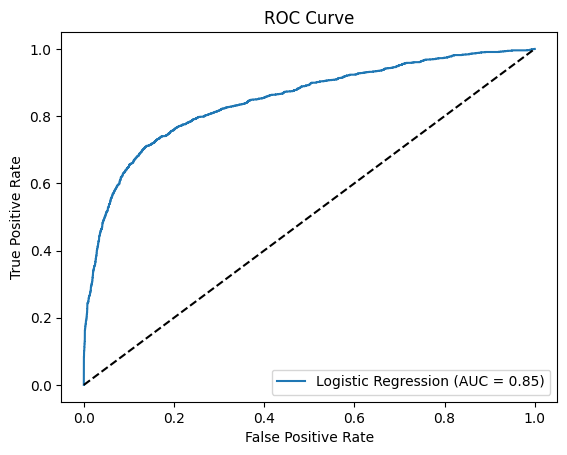

In [37]:
# Measure AUC-ROC
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = model.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_prob)
print("AUC-ROC:", auc_roc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (AUC = {:.2f})'.format(auc_roc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [38]:
#Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print("Cross-validated AUC scores:", cv_scores)
print("Mean AUC score:", np.mean(cv_scores))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

Cross-validated AUC scores: [0.85545411 0.8584423  0.83127278 0.84719796 0.85170653]
Mean AUC score: 0.8488147336527355


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## XG Boost

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:48:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:48:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:48:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:48:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr

Best AUC-ROC: 0.9522887914435847
Best parameters: {'learning_rate': 0.1, 'n_estimators': 300}


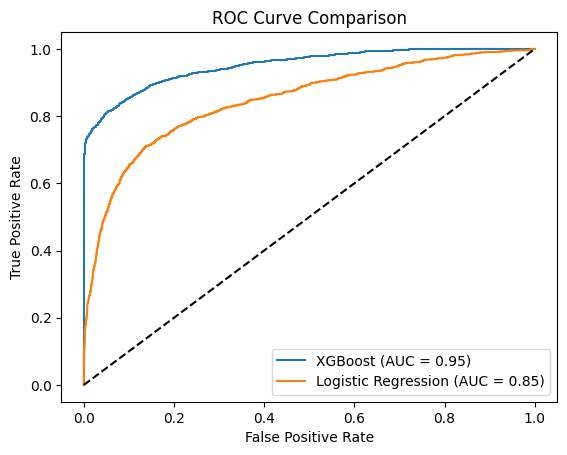

In [39]:
# XGBoost Model
from xgboost import XGBClassifier
#learining rates means how much the model learns from each tree, lower values can lead to better performance but require more trees
learning_rates = [0.01, 0.1, 0.2]
#n_estimators means the number of trees in the ensemble
n_estimators = [100, 200, 300]
best_auc = 0
best_params = {}
for lr in learning_rates:
    for n in n_estimators:
        #logloss means that the model is optimized for binary classification problems, and it will output probabilities for each class
        xgb_model = XGBClassifier(use_label_encoder=True, eval_metric='logloss', learning_rate=lr, n_estimators=n)
        xgb_model.fit(X_train, y_train)
        y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
        auc_roc_xgb = roc_auc_score(y_test, y_prob_xgb)
        if auc_roc_xgb > best_auc:
            best_auc = auc_roc_xgb
            best_params = {'learning_rate': lr, 'n_estimators': n}
print("Best AUC-ROC:", best_auc)
print("Best parameters:", best_params)

#Plot AUC-ROC for XGBoost
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = {:.2f})'.format(auc_roc_xgb))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = {:.2f})'.format(auc_roc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

<Figure size 1000x800 with 0 Axes>

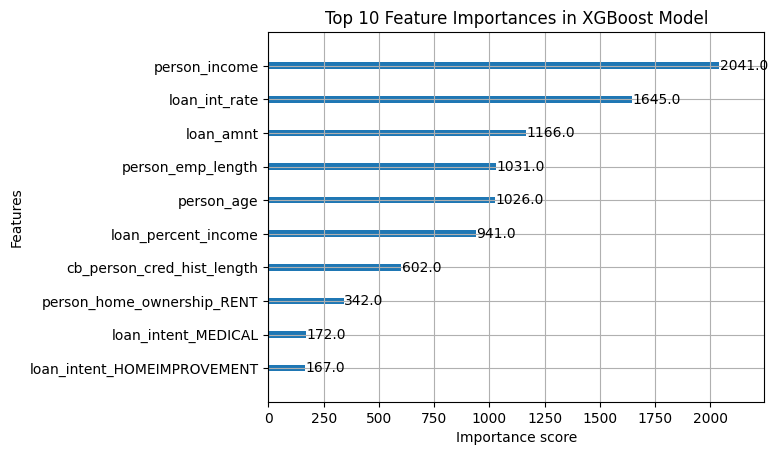

In [40]:
#Plotting feature importance for XGBoost
from xgboost import plot_importance
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=10)
plt.title('Top 10 Feature Importances in XGBoost Model')
plt.show()

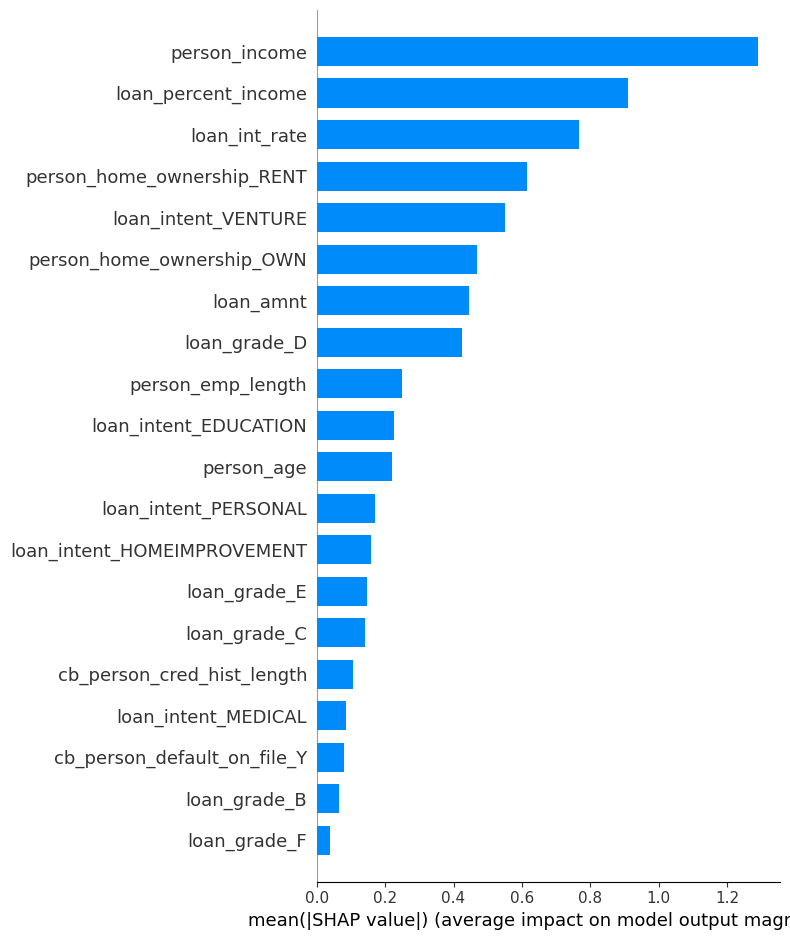

In [41]:
#Shapley values for interpretability
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")


## Light GBM

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: use_label_encoder
[LightGBM] [Info] Number of positive: 5686, number of negative: 20378
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 930
[LightGBM] [Info] Number of data points in the train set: 26064, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218155 -> initscore=-1.276449
[LightGBM] [Info] Start training from score -1.276449
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: use_label_encoder
LGBM AUC-ROC: 0.9540078867205237


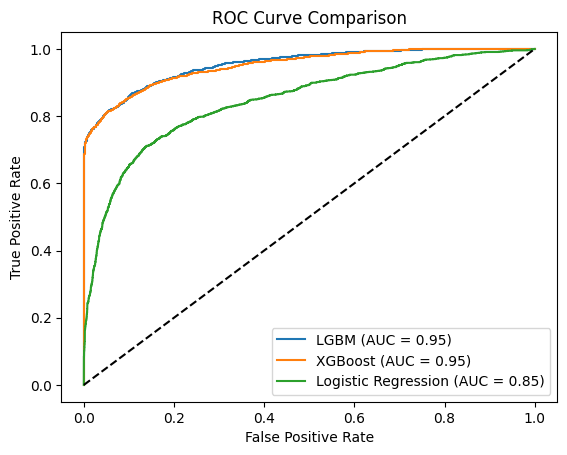

In [42]:
#Model for LGBM
from lightgbm import LGBMClassifier
#Learning rate and n_estimators are the same as XGBoost for consistency in comparison
#learning_rate=0.1 means that the model will learn at a moderate pace, allowing it to capture complex patterns without overfitting too quickly
#n_estimators=200 means that the model will build an ensemble of 200 trees, which can help improve performance by reducing bias and variance
#use_label_encoder=False is used to avoid warnings about label encoding in LightGBM, and eval_metric='logloss' specifies that the model should optimize for log loss, which is suitable for binary classification problems
#random_state=42 ensures reproducibility of results by setting a fixed seed for random number generation
#Overall, these parameters are chosen to balance model performance and training time while ensuring that the model is well-suited for the binary classification task at hand.
lgbm_model = LGBMClassifier(learning_rate=0.1, n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss')
lgbm_model.fit(X_train, y_train)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
auc_roc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
print("LGBM AUC-ROC:", auc_roc_lgbm)

#Plot AUC-ROC for LGBM
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test, y_prob_lgbm)
plt.figure()
plt.plot(fpr_lgbm, tpr_lgbm, label='LGBM (AUC = {:.2f})'.format(auc_roc_lgbm))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = {:.2f})'.format(auc_roc_xgb))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = {:.2f})'.format(auc_roc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()



## Stream Lit Application

In [53]:
one_hot_encoded_df.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'loan_grade_B', 'loan_grade_C',
       'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'],
      dtype='str')

In [54]:
#Streamlit app for interactive model exploration
import streamlit as st
st.title("Credit Risk Analysis Model Exploration")
st.write("This app allows you to evaluate the risk of a person based on their features using the trained models. You can input different feature values to see how they affect the predicted probability of default.")

#Check if user is likely to default based on input features
st.write("### Predict Default Risk")
#Create input fields for user to enter feature values
person_age = st.number_input("Person Age", min_value=18, max_value=100, value=30)
person_income = st.number_input("Person Income", min_value=0, value=50000)
person_emp_length = st.number_input("Person Employment Length (years)", min_value=0, max_value=50, value=5)
loan_amnt = st.number_input("Loan Amount", min_value=0, value=10000)
loan_int_rate = st.number_input("Loan Interest Rate (%)", min_value=0.0, max_value=100.0, value=10.0)
loan_grade = st.selectbox("Loan Grade", options=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
person_home_ownership = st.selectbox("Home Ownership", options=['RENT', 'OWN', 'MORTGAGE', 'OTHER'])
loan_intent = st.selectbox("Loan Intent", options=['EDUCATION', 'MEDICAL', 'VENTURE', 'PERSONAL', 'DEBTCONSOLIDATION'])
cb_person_default_on_file = st.selectbox("Credit Bureau Default on File", options=['Y', 'N'])
#Create a DataFrame for the input features
input_data = pd.DataFrame({
    'person_age': [person_age],
    'person_income': [person_income],
    'person_emp_length': [person_emp_length],
    'loan_amnt': [loan_amnt],
    'loan_int_rate': [loan_int_rate],
    'loan_grade_B': [1 if loan_grade == 'B' else 0],
    'loan_grade_C': [1 if loan_grade == 'C' else 0],
    'loan_grade_D': [1 if loan_grade == 'D' else 0],
    'loan_grade_E': [1 if loan_grade == 'E' else 0],
    'loan_grade_F': [1 if loan_grade == 'F' else 0],
    'loan_grade_G': [1 if loan_grade == 'G' else 0],
    'person_home_ownership_OWN': [1 if person_home_ownership == 'OWN' else 0],
    'person_home_ownership_RENT': [1 if person_home_ownership == 'RENT' else 0],
    'person_home_ownership_MORTGAGE': [1 if person_home_ownership == 'MORTGAGE' else 0],
    'person_home_ownership_OTHER': [1 if person_home_ownership == 'OTHER' else 0],
    'loan_intent_EDUCATION': [1 if loan_intent == 'EDUCATION' else 0],
    'loan_intent_MEDICAL': [1 if loan_intent == 'MEDICAL' else 0],
    'loan_intent_VENTURE': [1 if loan_intent == 'VENTURE' else 0],
    'loan_intent_PERSONAL': [1 if loan_intent == 'PERSONAL' else 0],
    'loan_intent_DEBTCONSOLIDATION': [1 if loan_intent == 'DEBTCONSOLIDATION' else 0],
    'cb_person_default_on_file_Y': [1 if cb_person_default_on_file == 'Y' else 0],
    'cb_person_default_on_file_N': [1 if cb_person_default_on_file == 'N' else 0]
})
#Predict default risk using the best model (XGBoost in this case)
predicted_prob = xgb_model.predict_proba(input_data)[:, 1][0]
st.write(f"Predicted Probability of Default: {predicted_prob:.2f}")
if predicted_prob > 0.5:
    st.write("The model predicts that this person is likely to default on the loan.")
else:
    st.write("The model predicts that this person is unlikely to default on the loan.")




2026-05-13 02:21:21.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.133 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.134 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-13 02:21:21.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

ValueError: feature_names mismatch: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_Y'] ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'loan_intent_EDUCATION', 'loan_intent_MEDICAL', 'loan_intent_VENTURE', 'loan_intent_PERSONAL', 'loan_intent_DEBTCONSOLIDATION', 'cb_person_default_on_file_Y', 'cb_person_default_on_f